# Home Credit Risk
After trying three ML models: logistic regresion, random forestand LightGBM. LightGBM gave us the best score for roc-auc. For this, we will try to find the best value for LightGBM parameters by tuning them using gridsearchCV.
This notebook is ordered by the following:
* First, tun LightGBM parameters by GridSearchCV
* Then, evaluate the best model and visualize classification metrics
* Find & plot important features
* Select features & save best model with its meta-data as a pickle

## 1. Import

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score,accuracy_score, classification_report,precision_recall_curve, accuracy_score, PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix,average_precision_score,roc_curve,make_scorer,precision_score, recall_score, f1_score
import numpy as np
from scipy.stats import randint, uniform
# import required modules
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from functions import *
import re
# Modeling
import lightgbm as lgb
# mlflow
import mlflow
from mlflow import MlflowClient
import mlflow.data
import gc

## 2. Read data

In [2]:
data = pd.read_parquet('../../data/preprocessed_data/min_train_108f.parquet')
data.shape

(307507, 109)

**Take %15 as a sample from the dataset**

In [3]:
data_sample = data.sample(frac=0.20,random_state =42)
data_sample.shape

(61501, 109)

In [4]:
# Fix column names, to avoid complexity with lgbm policy
data_sample.columns = [re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    for col in data_sample.columns]

In [5]:
# Find all columns with special characters
bad_cols = [
    col for col in data_sample.columns
    if re.search(r'[^A-Za-z0-9_]', str(col))]

print(f"Problematic columns: {bad_cols}")

Problematic columns: []


In [6]:
del data
gc.collect()

20

## 3. Split the data into train, validate & test

In [7]:
# Extract the labels
labels = data_sample['TARGET'].astype(np.int32)
data_sample = data_sample.drop(columns = ['TARGET', 'SK_ID_CURR'])

# Split into training, validating & testing data
X_train, X_temp, y_train, y_temp = train_test_split(data_sample, labels, test_size=0.4, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [8]:
del data_sample
gc.collect()

0

In [9]:
print("Training features shape: ", X_train.shape)
print("validating features shape: ", X_val.shape)
print("Testing features shape: ", X_test.shape)

Training features shape:  (36900, 107)
validating features shape:  (12300, 107)
Testing features shape:  (12301, 107)


In [10]:
#y_train.value_counts()

In [11]:
#y_val.value_counts()

In [12]:
#y_test.value_counts()

# 2. Modeling

In [13]:
client = MlflowClient(tracking_uri="http://127.0.0.1:5000")
projet1_exp1 = mlflow.set_experiment("projet1_exp_gridsearch_lgbm")

## 2. Grid search on LGBM parameters

**We will not using preprocesseur for scaling & imputation nan values, for the following reasons:**
* LightGBM doesn't need scaling, because LightGBM is a tree-based model, and Trees make decisions by finding the best split threshold on a feature
* LightGBM doesn't need imputation, LightGBM has a built-in NaN handler — it automatically learns the best direction to send missing values at each split

### 1. Define LGBM model & parameter grid

In [14]:
lgbm = lgb.LGBMClassifier(task='train',objective='binary',metric='auc',
                          learning_rate=0.01,subsample=0.9,is_unbalance=True)

In [15]:
# Hyperparameter grid
params_grid = {
    'num_leaves': [15, 25, 31], # max number of leaves in one tree
    'min_child_samples': list(range(50, 151,50)), # minimal number of data in one leaf
    'max_depth': list(range(3,8,2)), #limit the max depth for tree model
    'min_child_weight':list(range(1, 6,2)),# minimal sum hessian in one leaf
    'num_iteration': list(range(300,600,200)),
    'colsample_bytree':  [0.6, 0.8]
    }

"""
    'reg_alpha': list(np.linspace(0.1, 0.3,3)), #L1 regularization
    'reg_lambda': list(np.linspace(0.1, 0.3,3)), #L2 regularization
    'colsample_bytree': list(np.linspace(0.7, 1,3)), # subset of selected features on each iteration (tree)
    'subsample': list(np.linspace(0.7, 1, 4)), # randomly select part of data without resampling
    'min_split_gain': list(np.linspace(0.01, 0.05, 5)), # the minimal gain to perform split
"""


"\n    'reg_alpha': list(np.linspace(0.1, 0.3,3)), #L1 regularization\n    'reg_lambda': list(np.linspace(0.1, 0.3,3)), #L2 regularization\n    'colsample_bytree': list(np.linspace(0.7, 1,3)), # subset of selected features on each iteration (tree)\n    'subsample': list(np.linspace(0.7, 1, 4)), # randomly select part of data without resampling\n    'min_split_gain': list(np.linspace(0.01, 0.05, 5)), # the minimal gain to perform split\n"

### 2. Define GridSearchCv and its parameters

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=params_grid,
    scoring=make_scorer(fbeta_score, beta=10, zero_division=0),
    #scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

### 3. Run gridsearch inside mlflow

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Warning] num_iterations is set=500, num_iteration=500 will be ignored. Current value: num_iterations=500
[LightGBM] [Info] Number of positive: 3013, number of negative: 33887
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032622 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16254
[LightGBM] [Info] Number of data points in the train set: 36900, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081653 -> initscore=-2.420095
[LightGBM] [Info] Start training from score -2.420095
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

2026/05/15 12:30:03 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LGBM classifier on Train : ROC-AUC = 0.7891
LGBM classifier on Train : F1 score = 0.2930
LGBM classifier on Train  Accuracy: 0.7249
LGBM classifier on Train  fbeta score: 0.6797
LGBM classifier on validate: ROC-AUC = 0.7468
LGBM classifier on validate: F1 score = 0.2753
LGBM classifier on validate Accuracy: 0.7136
LGBM classifier on validate fbeta score: 0.6481


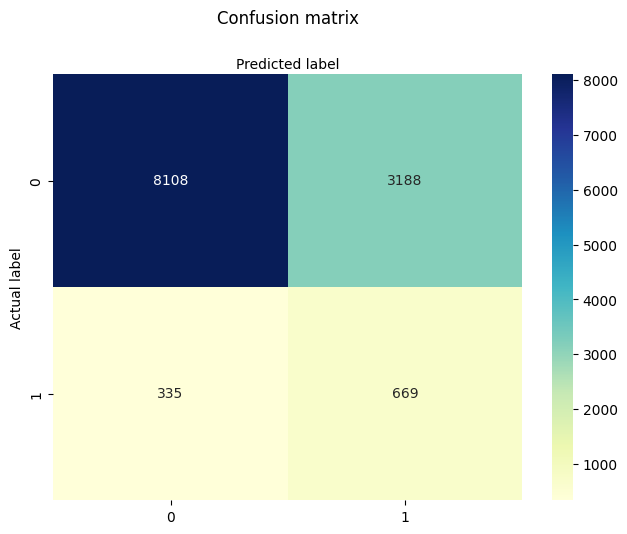

In [17]:
with mlflow.start_run(run_name="GridSeachCv LGBMclassifier fbeta scoring") as run:
    # Train the model
    grid_lgbm.fit(X_train,y_train)
    # Log the model
    best_model = grid_lgbm.best_estimator_
    model_info_lgb = mlflow.lightgbm.log_model(lgb_model=best_model, name="LGBMclassifier fbeta scoring for HomeCreditRisk")
    # Predict on the train set, compute and log the metrics
    y_pred_proba = best_model.predict_proba(X_train)[:, 1]               #get probablity
    y_pred = best_model.predict(X_train)
    t_roc_auc, t_f1, t_accuracy, t_fbeta = calcul_metric(y_train, y_pred, y_pred_proba)
    print(f"LGBM classifier on Train : ROC-AUC = {t_roc_auc:.4f}")
    print(f"LGBM classifier on Train : F1 score = {t_f1:.4f}")
    print(f"LGBM classifier on Train  Accuracy: {t_accuracy:.4f}")
    print(f"LGBM classifier on Train  fbeta score: {t_fbeta:.4f}")
    mlflow.log_metrics({"Train Roc-Auc score": t_roc_auc,
                        "Train F1 score": t_f1,
                        "Train Fbeta score":t_fbeta,
                        "Train accuracy": t_accuracy})
    # Predict on the validation set, compute and log the metrics
    y_val_pred_proba = best_model.predict_proba(X_val)[:, 1]               #get probablity
    y_val_pred = best_model.predict(X_val)
    v_roc_auc, v_f1, v_accuracy, v_fbeta = calcul_metric(y_val, y_val_pred, y_val_pred_proba)
    print(f"LGBM classifier on validate: ROC-AUC = {v_roc_auc:.4f}")
    print(f"LGBM classifier on validate: F1 score = {v_f1:.4f}")
    print(f"LGBM classifier on validate Accuracy: {v_accuracy:.4f}")
    print(f"LGBM classifier on validate fbeta score: {v_fbeta:.4f}")
    mlflow.log_metrics({"Validate Roc-Auc score": v_roc_auc,
                        "Validate F1 score": v_f1,
                        "Validate Fbeta score":v_fbeta,
                        "Validate accuracy": v_accuracy})
    cm = confusion_matrix(y_val, y_val_pred)
    plot_confusion_matrix(cm,["Repay loan","Not Repay loan"],"cm_lgbm_grid_fbeta_scoring")
    mlflow.log_artifact("./cm_lgbm_grid_fbeta_scoring.png")
    # Log the hyperparameters
    mlflow.log_params(best_model.get_params())
    mlflow.set_tag("Training Info", "GridSeach with fbeta scoring lgbm model for HomeCreditRisk data")

# 3. Evaluation & visualizations on validate dataset

## 1. Calculate & Plot roc-auc curve

In [18]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)

**Find optimal threshold in roc-auc curve**

Optimal Threshold value is: 0.5030667970118937


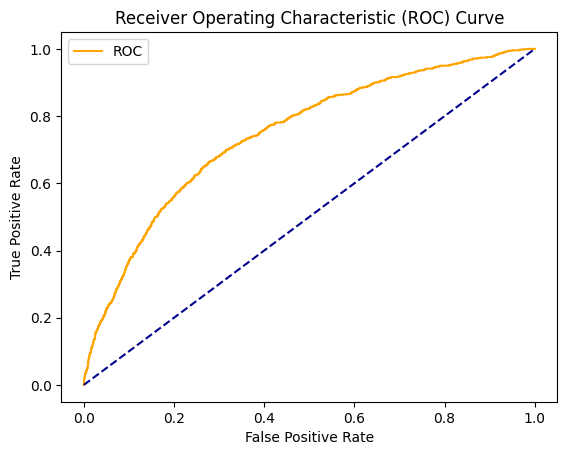

In [19]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold value is:", optimal_threshold)
plot_roc_curve(fpr, tpr)

## 2. Tune threshold on validation set

In [41]:
best_score,best_threshold,thresholds_scores = find_best_threshold(y_val_pred_proba,y_val,fbeta=10)
print(f"Best threshold:       {best_threshold:.2f}")
print(f"Best F2 score:        {best_score:.3f}")

Best threshold:       0.14
Best F2 score:        0.901


**Plot thresholds vs Fbeta scores**

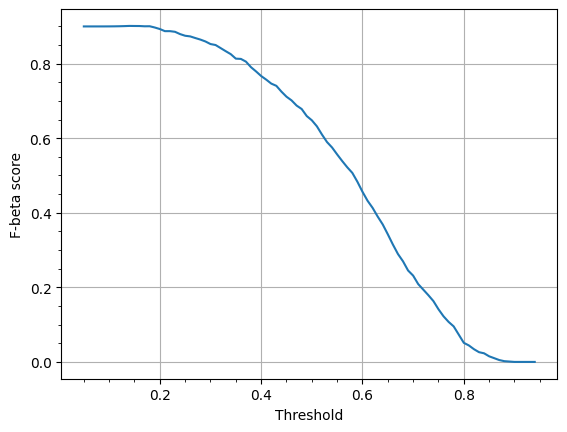

In [42]:
# unzip the list
thresholds, scores = zip(*thresholds_scores)
fig, ax = plt.subplots()
plt.plot(thresholds,scores)
plt.xlabel("Threshold")
plt.ylabel("F-beta score")
plt.grid()
plt.minorticks_on()

## 3. Calculate & plot confusion matrix with the new threshold
As we found the threshold with best score for fbeta on the validation dataset, we will test this threshold on unseen dataset i.e test dataset

In [43]:
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [44]:
test_pred_best_thr = (y_test_pred_proba>=best_threshold).astype(int)

In [ ]:
#list(test_pred_best_thr)

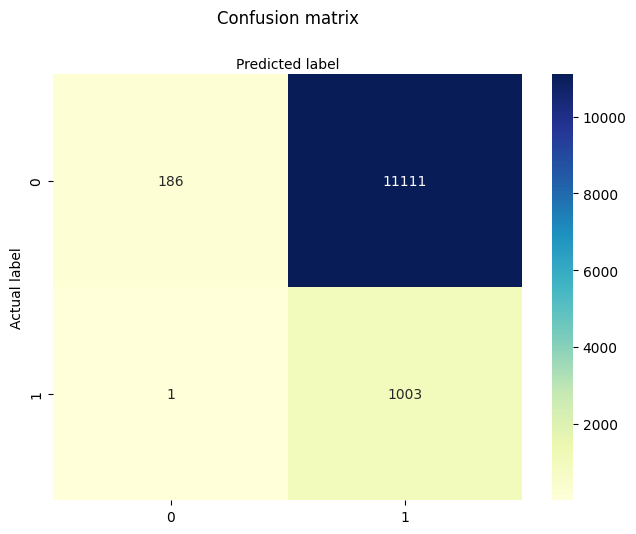

In [45]:
cm2 = confusion_matrix(y_test, test_pred_best_thr)
plot_confusion_matrix(cm2,["Repay loan","Not Repay loan"],"cm lgbm fbeta scoring for best thr")

# 4. Feature importance

## 1. Feature importance by LGBM

In [27]:
print(f"Best hyperparameters: {grid_lgbm.best_params_}")

Best hyperparameters: {'colsample_bytree': 0.8, 'max_depth': 3, 'min_child_samples': 100, 'min_child_weight': 1, 'num_iteration': 500, 'num_leaves': 15}


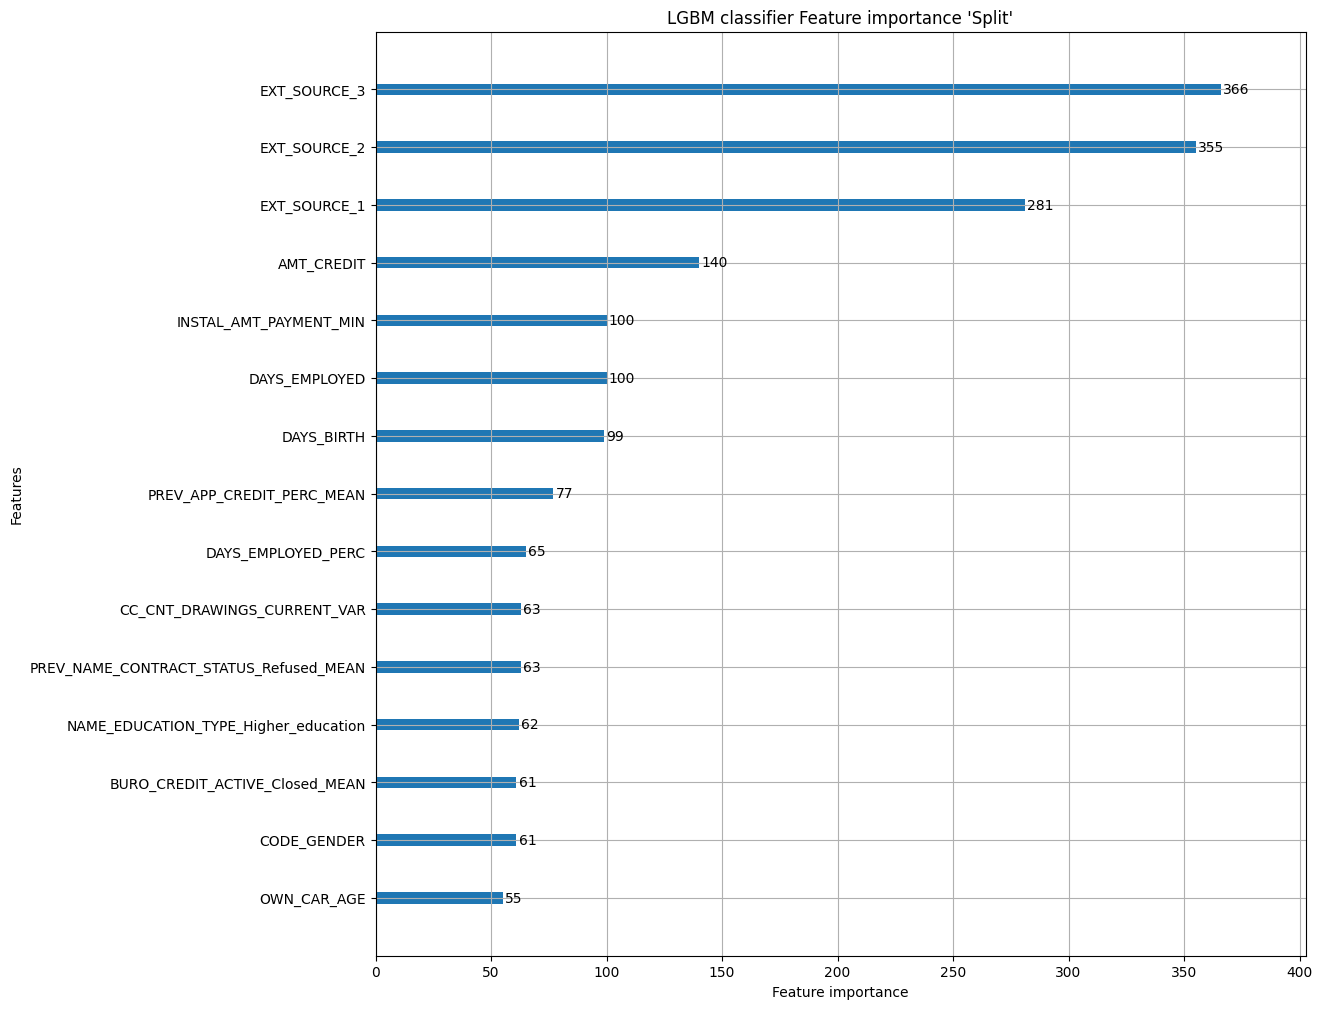

In [28]:
lgb.plot_importance(best_model,importance_type="split", figsize=(12, 12), max_num_features=15, title="LGBM classifier Feature importance 'Split'");
plt.show()

## 2. Feature importance by Shap

SHAP values show how each feature affects each final prediction, the significance of each feature compared to others, and the model's reliance on the interaction between features.

SHAP values are based on game theory and assign an importance value to each feature in a model. Features with positive SHAP values positively impact the prediction, while those with negative values have a negative impact. The magnitude is a measure of how strong the effect is.
SHAP values of all the input features will always sum up to the difference between baseline (expected) model output and the current model output for the prediction being explained.

In [29]:
import shap
shap.initjs()

In [30]:
# We will first create an explainer object by providing a LGBM classification model, then calculate SHAP value using a testing set
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

In [31]:
type(shap_values[1])

shap._explanation.Explanation

### 1. Global feature importance

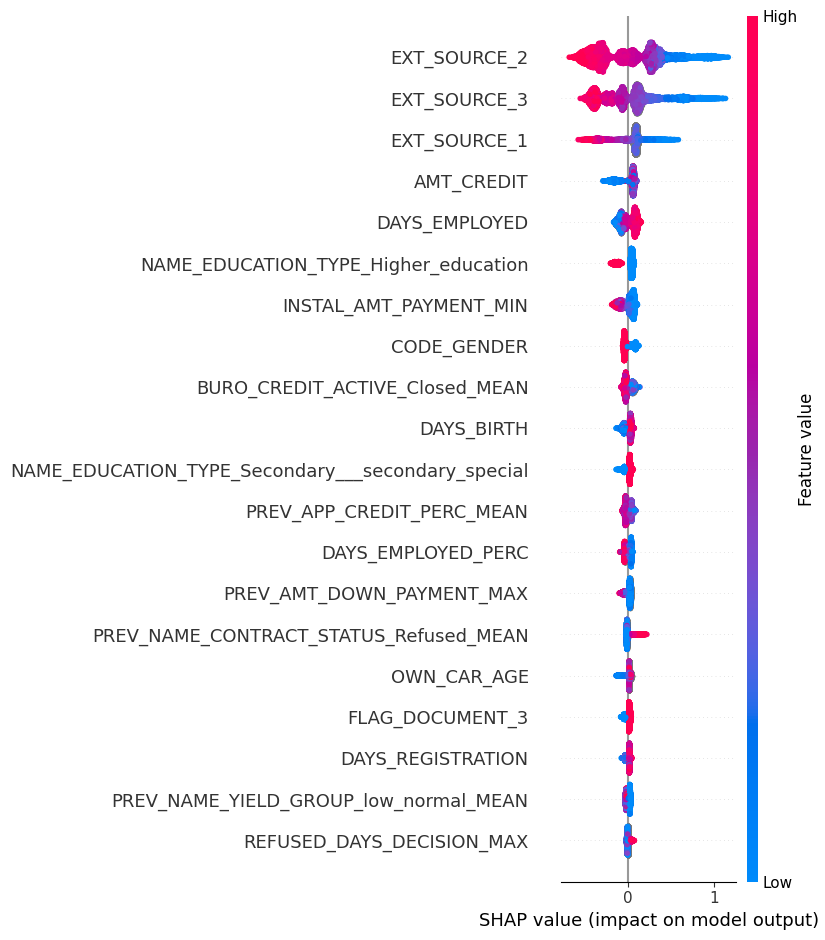

In [32]:
# The summary plot shows the feature importance of each feature in the model.
shap.summary_plot(shap_values, X_test)

### 2. Local feature importance
**We will examine the first sample in the testing set to determine which features contributed to the "0" result (Client repay loan)**

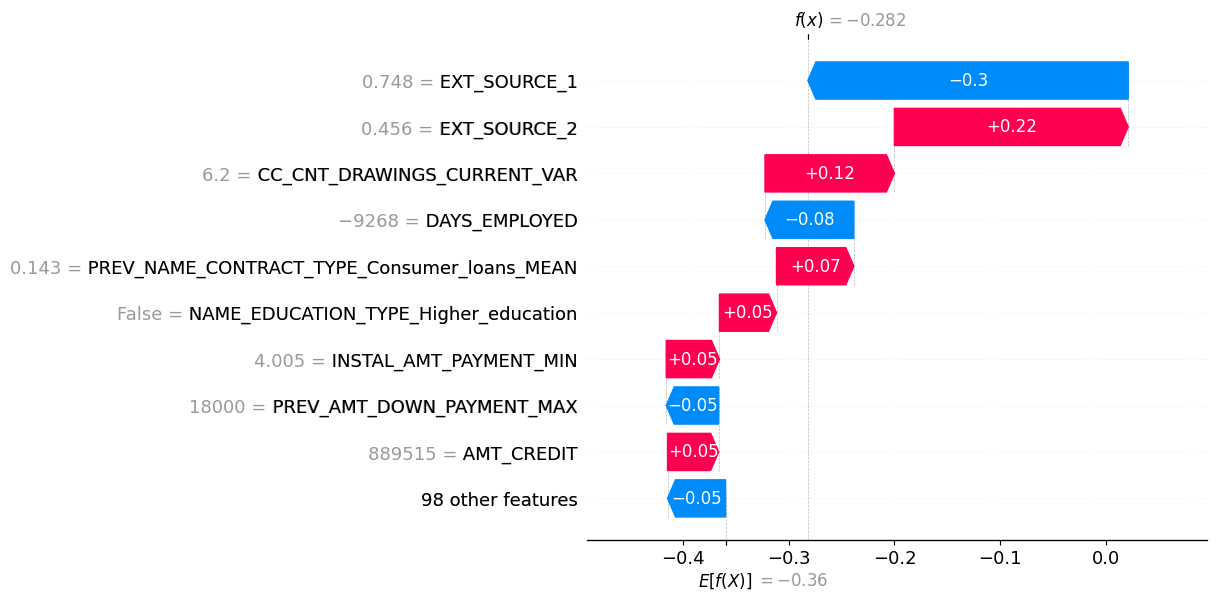

In [33]:
shap.plots.waterfall(shap_values[0])

From this plot we can see that:
* SHAP values for EXT_SOURCE_1  = -0.36 & DAYs_EMPLOYED = -0.9 , means these features increase the probability of class 0 (client repay loan) for this specific prediction.
* SHAP value for EXT_SOURCE_2 = +0.1 means this feature decreases the probability of class 0 (client repay loan) for this specific prediction.

**We will examine the 23 sample in the testing set to determine which features contributed to the "1" result (Client not repay loan)**

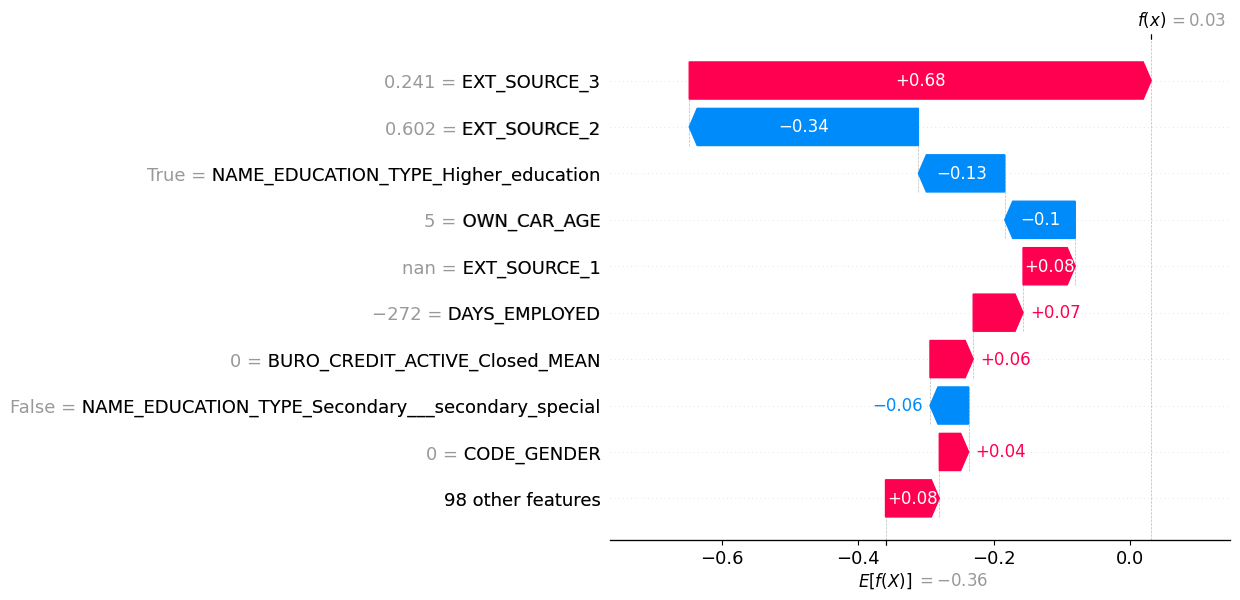

In [34]:
shap.plots.waterfall(shap_values[23])

From this plot we can see that:
* SHAP value for EXT_SOURCE_3 = +0.74 means this feature increases the probability of class 1 (client not repay loan) for this specific prediction.
* SHAP value for EXT_SOURCE_2 =-0.28 means this feature decreases the probability of class 1 (client not repay loan) for this specific prediction.

# 5. Select features & save model
As we saw above, among the 107 features used to train the model, there is just a group of features which contribute the most in prediction process. For this reason we will choose the top 20 most important features of the best model.

## 1.Select the top 20 important features

In [35]:
importance_df = pd.DataFrame({
        'feature':    best_model.feature_name_,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)

In [36]:
important_features = list(importance_df['feature'])

In [37]:
important_features

['EXT_SOURCE_3',
 'EXT_SOURCE_2',
 'EXT_SOURCE_1',
 'AMT_CREDIT',
 'DAYS_EMPLOYED',
 'INSTAL_AMT_PAYMENT_MIN',
 'DAYS_BIRTH',
 'PREV_APP_CREDIT_PERC_MEAN',
 'DAYS_EMPLOYED_PERC',
 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
 'CC_CNT_DRAWINGS_CURRENT_VAR',
 'NAME_EDUCATION_TYPE_Higher_education',
 'CODE_GENDER',
 'BURO_CREDIT_ACTIVE_Closed_MEAN',
 'OWN_CAR_AGE',
 'PREV_AMT_DOWN_PAYMENT_MAX',
 'DAYS_REGISTRATION',
 'PREV_AMT_ANNUITY_MAX',
 'NAME_EDUCATION_TYPE_Secondary___secondary_special',
 'PREV_NAME_PRODUCT_TYPE_walk_in_MEAN']

## 2. Save best model as pickle

In [46]:
import joblib

# Bundle model with useful metadata
model_bundle = {
    'model':          best_model,
    'feature_names':  important_features,
    'target_names':   ['Repay_loan', 'Not_repay_loan'],
    'threshold_fbeta10':      best_threshold,
    'best_params':    grid_lgbm.best_params_,
    'all_params':     best_model.get_params(),
    'metrics': {
        'train_roc':   t_roc_auc,
        'test_roc':    v_roc_auc,
    }
}

joblib.dump(model_bundle, '../model/grid_fbeta_model_bundle.pkl', compress=3)

['./best_model/grid_fbeta_model_bundle.pkl']

In [39]:
features = important_features.copy()
features.append('Target')

**Save train & test datasets with the selected features to be used later on**

In [47]:
df_train = X_train.copy()
df_train['Target'] = y_train
print('Train dataset shape:' , df_train.shape)
df_test = X_test.copy()
df_test['Target'] = y_test
print('Test dataset shape:' , df_test.shape)

Train dataset shape: (36900, 108)
Test dataset shape: (12301, 108)


In [48]:
df_train[features].to_parquet('../data/training_data/train_data_bestFeatures.parquet')
df_test[features].to_parquet('../data/training_data/test_data_bestFeatures.parquet')